In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from kelly_utils import kelly, drawdown

In [42]:
# USER SETTINGS

periods = 12
n_years = 30

burn_in = 1000

max_leverage = 10.0
min_leverage = 0.0

f = 0.75

Rebalancing = 12  # Times per year

scale_long = "none"  # options: "none", "same_avg_vol", "vol_targeting"

sharpe = "constant"  # options: "constant", "variable"

annual_ret = 0.05

SR = 0.40  # Expected annualized sharpe ratio.

m = 0.02  # degree of momentum

use_momentum = True
use_TC = True
return_paths = True

# Parameters for volatility simulations

p_LL = 0.999
p_HH = 0.99
vol_low_annual = 0.15
vol_high_annual = 0.40
rho = 0.95
std_lns = 0.05
jump_prob = 1 / periods
jump_size = 0.30

c = SR / np.sqrt(periods)

In [43]:
results = kelly(
    n_years,
    periods,
    burn_in,
    p_LL,
    p_HH,
    vol_low_annual,
    vol_high_annual,
    rho,
    std_lns,
    jump_prob,
    jump_size,
    c,
    m,
    annual_ret,
    sharpe,
    f,
    min_leverage,
    max_leverage,
    Rebalancing,
    scale_long,
    use_momentum,
    use_TC,
    return_paths
)

In [44]:
table = pd.DataFrame({
    "Buy-and-Hold": {
        "Sharpe ratio": results["sharpe_long"],
        "Modified SR": results["mod_sharpe_long"],
        "Final Wealth": results["final_wealth_long"],
        "Max Drawdown": results["max_dd_long"],
    },
    "Kelly": {
        "Sharpe ratio": results["sharpe_kelly"],
        "Modified SR": results["mod_sharpe_kelly"],
        "Final Wealth": results["final_wealth_kelly"],
        "Max Drawdown": results["max_dd_kelly"],
    },
    "Vol Targeting": {
        "Sharpe ratio": results["sharpe_volTarget"],
        "Modified SR": results["mod_sharpe_volTarget"],
        "Final Wealth": results["final_wealth_volTarget"],
        "Max Drawdown": results["max_dd_volTarget"],
    }
})

# Round for display
print(table.round(4))

              Buy-and-Hold    Kelly  Vol Targeting
Sharpe ratio        0.1937   0.4305         0.2923
Modified SR         0.2052   0.5478         0.3324
Final Wealth        1.7472  18.5344         3.1271
Max Drawdown       -0.7117  -0.8195        -0.5416


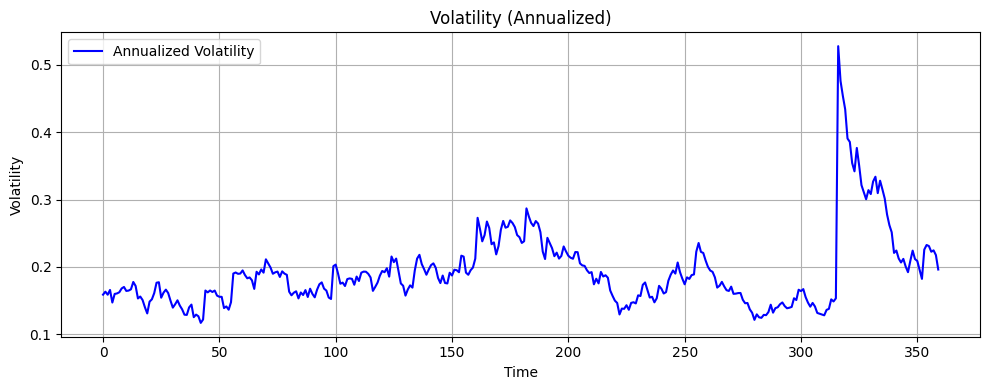

In [45]:
# Plot volatility path (annualized)
plt.figure(figsize=(10, 4))
plt.plot(results["volatility_path"], label="Annualized Volatility", color="blue")
plt.title("Volatility (Annualized)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

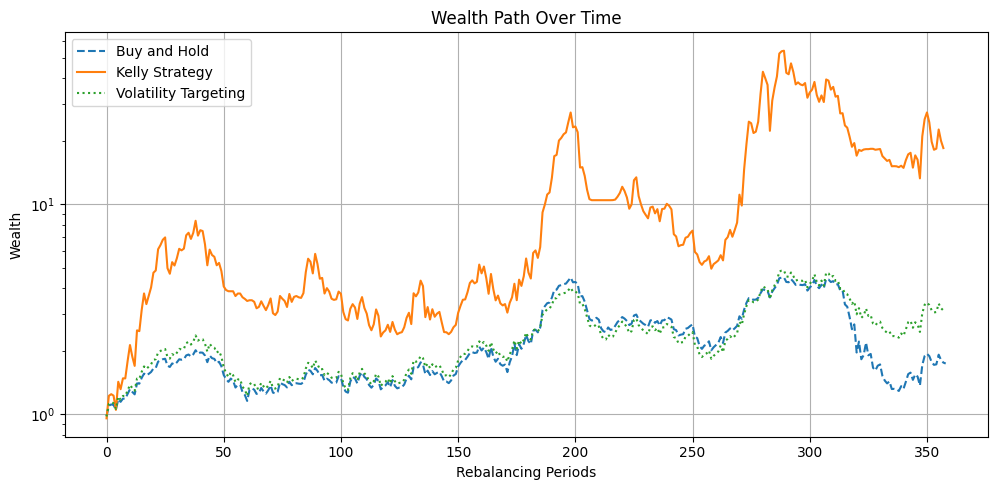

In [46]:
# Plot wealth paths
plt.figure(figsize=(10, 5))
plt.plot(results["wealth_paths"]["buy_and_hold"], label="Buy and Hold", linestyle="--")
plt.plot(results["wealth_paths"]["kelly"], label="Kelly Strategy", linestyle="-")
plt.plot(results["wealth_paths"]["vol_target"], label="Volatility Targeting", linestyle=":")
plt.title("Wealth Path Over Time")
plt.xlabel("Rebalancing Periods")
plt.ylabel("Wealth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale("log")
plt.show()


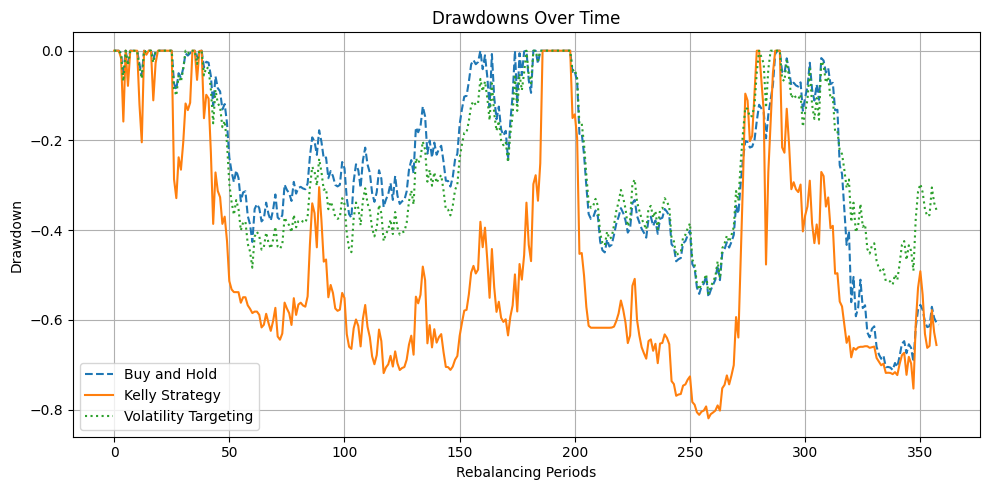

In [47]:
# Compute drawdowns
dd_long = drawdown(results["wealth_paths"]["buy_and_hold"])
dd_kelly = drawdown(results["wealth_paths"]["kelly"])
dd_volT = drawdown(results["wealth_paths"]["vol_target"])

# Plot drawdowns
plt.figure(figsize=(10, 5))
plt.plot(dd_long, label="Buy and Hold", linestyle="--")
plt.plot(dd_kelly, label="Kelly Strategy", linestyle="-")
plt.plot(dd_volT, label="Volatility Targeting", linestyle=":")
plt.title("Drawdowns Over Time")
plt.xlabel("Rebalancing Periods")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [48]:
kelly_w = results["kelly_weights"]
volT_w = results["vol_target_weights"]

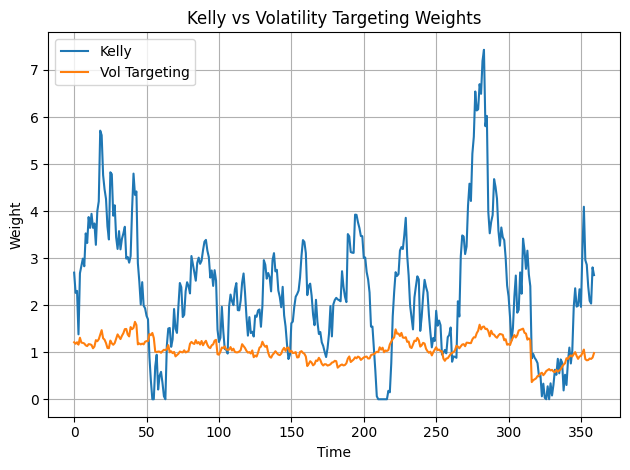

In [49]:
plt.plot(kelly_w, label="Kelly")
plt.plot(volT_w, label="Vol Targeting")
plt.title("Kelly vs Volatility Targeting Weights")
plt.xlabel("Time")
plt.ylabel("Weight")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


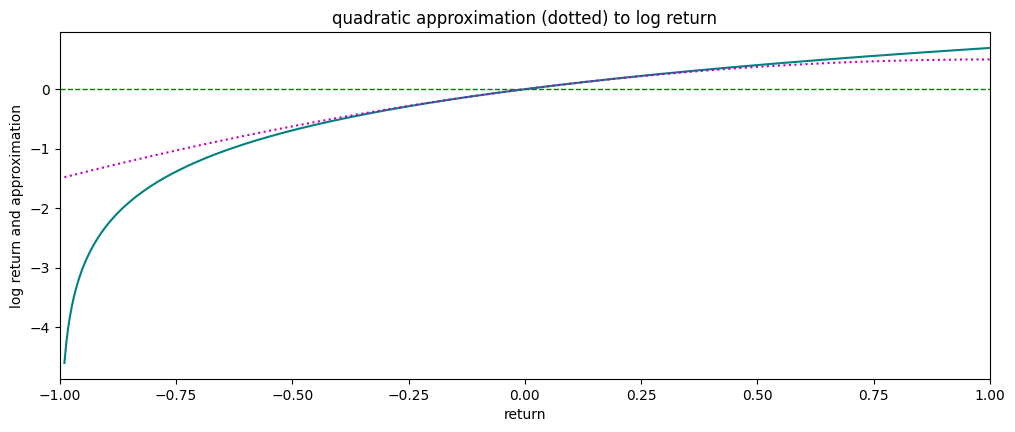

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Define return range: avoid -1 to prevent log(0)
r = np.linspace(-0.99, 1.0, 500)

# Functions
log_return = np.log(1 + r)
quad_approx = r - 0.5 * r**2

# Plot
plt.figure(figsize=(12, 4.5))
plt.plot(r, log_return, label='log(1 + r)', color='teal')
plt.plot(r, quad_approx, 'm:', label='r - 0.5 * r^2 (approximation)')
plt.axhline(y=0, color='green', linestyle='--', linewidth=1)  # x-axis

# No y-axis plotted, so the dotted line appears to hit y-axis
plt.title('quadratic approximation (dotted) to log return')
plt.xlabel('return')
plt.ylabel('log return and approximation')
plt.grid(False)

# Optional: set tight x limits to push curves close to y-axis
plt.xlim(-1.0, 1.0)

plt.savefig("approx.png", dpi=300, bbox_inches='tight')

plt.show()
